# Deep Momentum — Full Pipeline Run

Replication of Han & Qin (2026), "Bimodality Everywhere: International Evidence of Deep Momentum"

Pilot run: US, Canada, Australia

In [1]:
import warnings
warnings.filterwarnings('ignore')

PILOT_COUNTRIES = ['TO', 'OL', 'AT']  # Canada, Norway, Austria
N_ENSEMBLE = 100  # paper uses 100
OOS_START = '2010-01-31'  # paper's OOS start

print('Pilot countries:', PILOT_COUNTRIES)
print(f'Ensemble size: {N_ENSEMBLE}')

Pilot countries: ['TO', 'OL', 'AT']
Ensemble size: 100


## Step 1: Data Fetch

In [2]:
from data_fetch import fetch_all_countries

raw_data = fetch_all_countries(
    suffixes=PILOT_COUNTRIES,
    max_stocks_per_country=None,  # all stocks
    min_date='1990-01-01',
    save=True,
)


Fetching Canada (.TO)
  Found 2052 symbols


  TO: 100%|█████████████████████████████████| 2052/2052 [58:00<00:00,  1.70s/it]


  Retrieved: 1951 stocks, 322875 monthly obs, 101 errors
  Saved: /Users/galamboslajos/Desktop/Finance-Working-Files/Investments_2026/deep_momentum/data/monthly_TO.parquet (322875 rows)

Fetching Norway (.OL)
  Found 336 symbols


  OL: 100%|███████████████████████████████████| 336/336 [09:21<00:00,  1.67s/it]


  Retrieved: 308 stocks, 49029 monthly obs, 28 errors
  Saved: /Users/galamboslajos/Desktop/Finance-Working-Files/Investments_2026/deep_momentum/data/monthly_OL.parquet (49029 rows)

Fetching Austria (.AT)
  Found 100 symbols


  AT: 100%|███████████████████████████████████| 100/100 [04:31<00:00,  2.72s/it]

  Retrieved: 98 stocks, 29173 monthly obs, 2 errors
  Saved: /Users/galamboslajos/Desktop/Finance-Working-Files/Investments_2026/deep_momentum/data/monthly_AT.parquet (29173 rows)


## Step 2: Data Filtering

In [4]:
from data_filter import filter_country, check_country_eligibility
from config import COUNTRIES, DATA_DIR, CACHE_DIR
from pathlib import Path
import pandas as pd

for suffix in PILOT_COUNTRIES:
    _, country_name, _, _ = COUNTRIES[suffix]
    f = Path(DATA_DIR) / f'monthly_{suffix}.parquet'
    if not f.exists():
        print(f'No data for {suffix}')
        continue
    df = pd.read_parquet(f)
    filtered = filter_country(df, country_name)
    filtered.to_parquet(Path(CACHE_DIR) / f'filtered_{suffix}.parquet', index=False)
    eligible, reason = check_country_eligibility(filtered, suffix)
    print(f'  Eligible: {eligible} — {reason}')


  Canada: 1951 stocks, 322875 obs
    Zero volume filter: dropped 1294 obs (0.4%)
    MCap missing filter: dropped 2408 obs (0.8%)
    MCap bottom 5% filter: dropped 59239 obs (18.7%), removed 349 stocks
    Extreme return filter: dropped 91 obs (0.0%)
    Winsorize: clipped 5158 obs at [-0.3164, 0.4708]
    After all filters: 1600 stocks, 257892 obs
  Eligible: False — min stocks/month = 2, need >=30

  Norway: 308 stocks, 49029 obs
    Zero volume filter: dropped 186 obs (0.4%)
    MCap missing filter: dropped 466 obs (1.0%)
    MCap bottom 5% filter: dropped 12884 obs (26.8%), removed 80 stocks
    Extreme return filter: dropped 13 obs (0.0%)
    Winsorize: clipped 703 obs at [-0.3333, 0.4452]
    After all filters: 227 stocks, 35172 obs
  Eligible: False — min stocks/month = 5, need >=30

  Austria: 98 stocks, 29173 obs
    Zero volume filter: dropped 291 obs (1.0%)
    MCap missing filter: dropped 404 obs (1.4%)
    MCap bottom 5% filter: dropped 8706 obs (30.7%), removed 28 stoc

## Step 3: Feature Construction

In [5]:
from features import build_features
from config import COUNTRIES, CACHE_DIR
from pathlib import Path
import pandas as pd

cache_dir = Path(CACHE_DIR)
features_data = {}

for suffix in PILOT_COUNTRIES:
    filtered_path = cache_dir / f'filtered_{suffix}.parquet'
    if not filtered_path.exists():
        print(f'No filtered data for {suffix}, skipping')
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df = pd.read_parquet(filtered_path)
    df, feature_cols = build_features(df, country_name)
    
    # Save
    df.to_parquet(cache_dir / f'features_{suffix}.parquet', index=False)
    features_data[suffix] = (df, feature_cols)
    
print(f'\nFeatures built for {len(features_data)} countries')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

  Building features for Canada...
    Stocks: 1600
    Total obs: 257892
    Complete obs (all features + label): 238880
    Feature cols: 16
  Building features for Norway...
    Stocks: 227
    Total obs: 35172
    Complete obs (all features + label): 32476
    Feature cols: 16
  Building features for Austria...
    Stocks: 70
    Total obs: 19662
    Complete obs (all features + label): 18831
    Feature cols: 16

Features built for 3 countries
Feature columns (16): ['zMOM_1', 'MMOM_1', 'SMOM_1', 'zMOM_3', 'MMOM_3', 'SMOM_3', 'zMOM_6', 'MMOM_6', 'SMOM_6', 'zMOM_9', 'MMOM_9', 'SMOM_9', 'zMOM_12', 'MMOM_12', 'SMOM_12', 'SIZE']


## Step 4: Model Training + Prediction

In [6]:
from model import run_walk_forward

predictions_data = {}

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    
    print(f'\n{"="*60}')
    print(f'TRAINING: {country_name} (.{suffix})')
    print(f'{"="*60}')
    
    predictions = run_walk_forward(
        df, feature_cols,
        n_ensemble=N_ENSEMBLE,
        verbose=True,
    )
    
    if not predictions.empty:
        predictions.to_parquet(cache_dir / f'predictions_{suffix}.parquet', index=False)
        predictions_data[suffix] = predictions
        print(f'  Saved {len(predictions)} predictions')
    else:
        print(f'  No predictions generated')

print(f'\nPredictions generated for {len(predictions_data)} countries')


TRAINING: Canada (.TO)
    Training schedule: 27 retrainings
    First train: 2000-04-01
    Last train: 2026-04-01
    Training at 2000-04-01, predicting 12 months...
    Training at 2001-04-01, predicting 12 months...
    Training at 2002-04-01, predicting 12 months...
    Training at 2003-04-01, predicting 12 months...
    Training at 2004-04-01, predicting 12 months...
    Training at 2005-04-01, predicting 12 months...
    Training at 2006-04-01, predicting 12 months...
    Training at 2007-04-01, predicting 12 months...
    Training at 2008-04-01, predicting 12 months...
    Training at 2009-04-01, predicting 12 months...
    Training at 2010-04-01, predicting 12 months...
    Training at 2011-04-01, predicting 12 months...
    Training at 2012-04-01, predicting 12 months...
    Training at 2013-04-01, predicting 12 months...
    Training at 2014-04-01, predicting 12 months...
    Training at 2015-04-01, predicting 12 months...
    Training at 2016-04-01, predicting 12 months...

## Step 5: Portfolio Construction + Performance

In [7]:
from portfolio import run_all_strategies, print_performance_table

all_results = {}

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data or suffix not in predictions_data:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    predictions = predictions_data[suffix]
    
    # Merge fwd_return into predictions
    fwd = df[['symbol', 'date', 'fwd_return']].dropna()
    predictions = predictions.drop(columns=['fwd_return'], errors='ignore')
    predictions = predictions.merge(fwd, on=['symbol', 'date'], how='left')
    
    print(f'\n{"="*60}')
    print(f'{country_name}')
    print(f'{"="*60}')
    
    results = run_all_strategies(df, predictions, oos_start=OOS_START)
    print_performance_table(results)
    all_results[suffix] = results


Canada

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months
---------------------------------------------------------------------------
MOM            22.6%     21.4%    1.053   2483.5%  -28.2%     4.23     194
XGB            13.7%     13.3%    1.033    684.1%  -20.2%     4.14     193
RET            -4.8%     17.3%   -0.279    -63.9%  -80.1%    -1.12     194
SRP           -15.2%     16.8%   -0.903    -93.3%  -95.8%    -3.63     194

Norway

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months
---------------------------------------------------------------------------
MOM            26.9%     24.3%    1.107   4551.4%  -34.2%     4.45     194
XGB            13.4%     17.1%    0.785    577.6%  -43.6%     3.15     193
RET           -14.1%     21.8%   -0.647    -93.0%  -96.1%    -2.59     193
SRP           -10.6%     22.7%   -0.468    -88.1%  -95.4%    -1.88     193

Austria

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD 

## Step 6: Full Report + Metrics

In [8]:
from metrics import full_report

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data or suffix not in predictions_data:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    predictions = predictions_data[suffix]
    
    # Merge fwd_return
    fwd = df[['symbol', 'date', 'fwd_return']].dropna()
    preds = predictions.drop(columns=['fwd_return'], errors='ignore')
    preds = preds.merge(fwd, on=['symbol', 'date'], how='left')
    
    full_report(df, preds, all_results.get(suffix, {}), country_name)


FULL REPORT — Canada

--- Portfolio Performance (Table 5 equivalent) ---
Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months
---------------------------------------------------------------------------
MOM            22.6%     21.4%    1.053   2483.5%  -28.2%     4.23     194
XGB            13.7%     13.3%    1.033    684.1%  -20.2%     4.14     193
RET            -4.8%     17.3%   -0.279    -63.9%  -80.1%    -1.12     194
SRP           -15.2%     16.8%   -0.903    -93.3%  -95.8%    -3.63     194

--- Bimodality (Table 2 equivalent) ---
  MOM:  HH=0.086  HL=0.049  LL=0.165  LH=0.097  BM=-0.053
  XGB:  HH=0.120  HL=0.105  LL=0.148  LH=0.097  BM=-0.033

--- Crash Rate ---
  MOM: 0.170
  XGB: 0.000
  RET: 0.344
  SRP: 0.381

--- Classification Accuracy (Table IA2 equivalent) ---
  Overall accuracy: 17.4%
  Precision H: 22.2%  Precision L: 25.5%
  Recall H: 23.9%  Recall L: 43.8%
  Pred ratio H: 10.7%  Pred ratio L: 17.6%

FULL REPORT — Norway

--- Portfolio Perf

## Plots

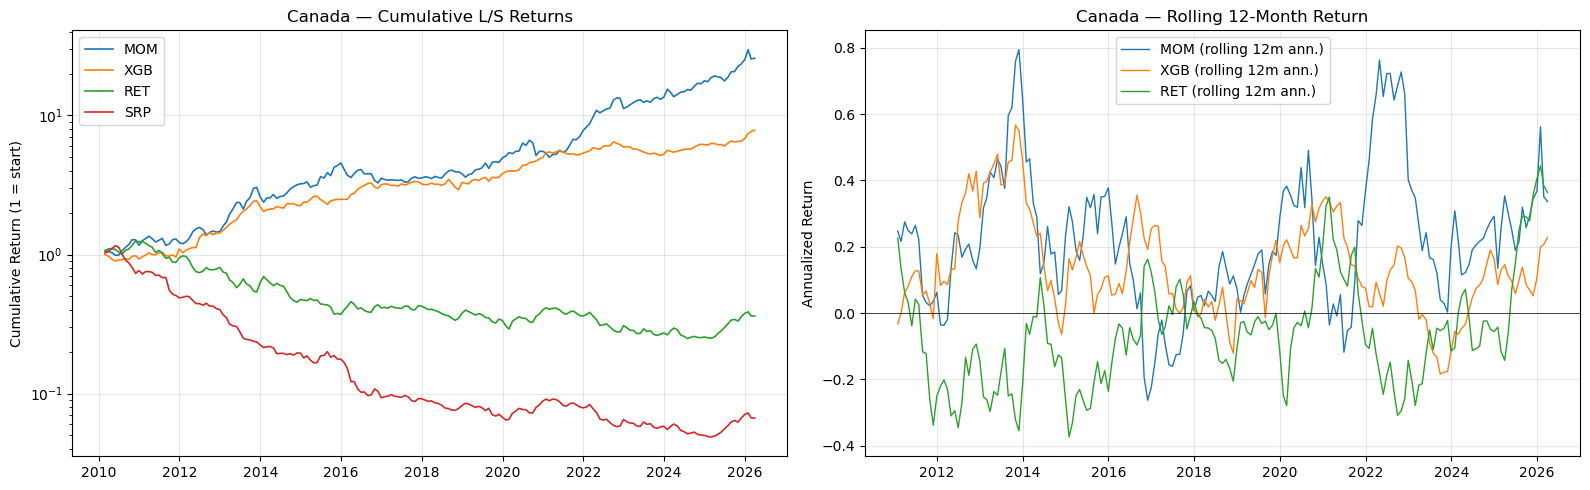

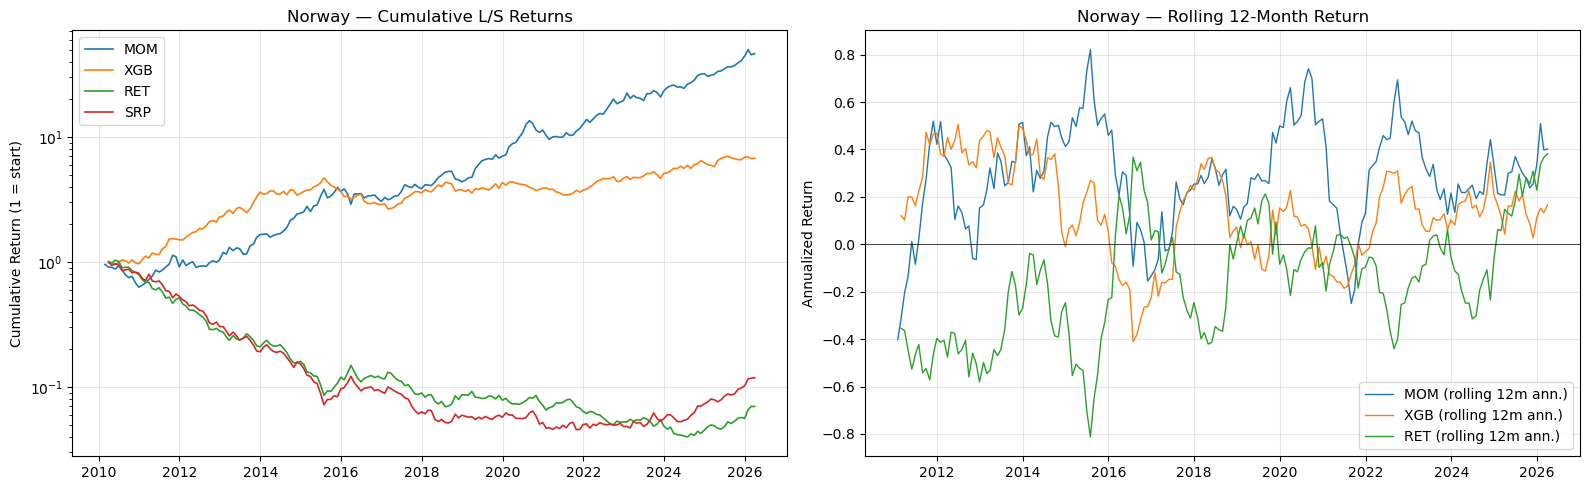

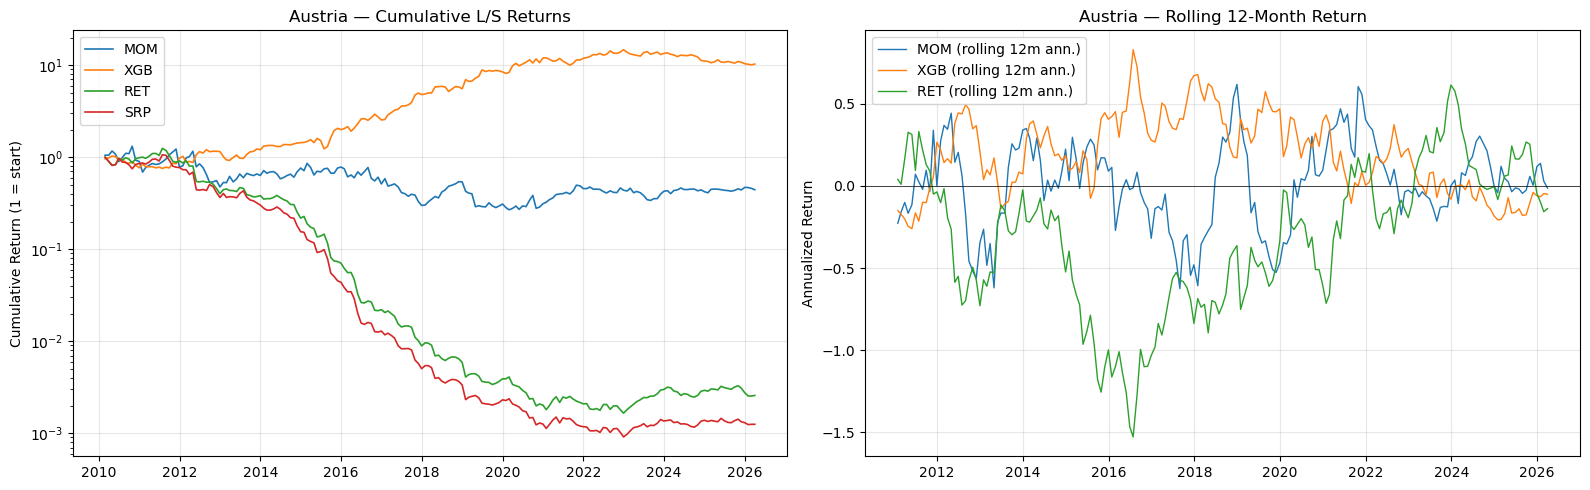

In [9]:
import matplotlib.pyplot as plt
import numpy as np

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Panel 1: Cumulative returns
    ax = axes[0]
    for name, color in [('MOM', '#1f77b4'), ('XGB', '#ff7f0e'), ('RET', '#2ca02c'), ('SRP', '#d62728')]:
        if name in all_results[suffix] and not all_results[suffix][name]['portfolio'].empty:
            port = all_results[suffix][name]['portfolio']
            cum = (1 + port['ls_ret']).cumprod()
            ax.plot(port['date'], cum, label=name, color=color, linewidth=1.2)
    
    ax.set_ylabel('Cumulative Return (1 = start)')
    ax.set_title(f'{country_name} — Cumulative L/S Returns')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_yscale('log')
    
    # Panel 2: Rolling 12-month return
    ax = axes[1]
    for name, color in [('MOM', '#1f77b4'), ('XGB', '#ff7f0e'), ('RET', '#2ca02c')]:
        if name in all_results[suffix] and not all_results[suffix][name]['portfolio'].empty:
            port = all_results[suffix][name]['portfolio']
            rolling = port['ls_ret'].rolling(12).mean() * 12
            ax.plot(port['date'], rolling, label=f'{name} (rolling 12m ann.)', 
                    color=color, linewidth=1)
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('Annualized Return')
    ax.set_title(f'{country_name} — Rolling 12-Month Return')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'results/{suffix}_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print()

## Cross-Country Comparison (Table 5 equivalent)

In [10]:
print(f'{"Country":<15s} {"":>5s} {"MOM":>12s} {"XGB":>12s} {"RET":>12s} {"SRP":>12s}')
print(f'{"":>20s} {"Ret / Sharpe":>12s} {"Ret / Sharpe":>12s} {"Ret / Sharpe":>12s} {"Ret / Sharpe":>12s}')
print('-' * 75)

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results:
        continue
    _, country_name, _, _ = COUNTRIES[suffix]
    
    parts = [f'{country_name:<15s}', f'{"":>5s}']
    for name in ['MOM', 'XGB', 'RET', 'SRP']:
        if name in all_results[suffix] and all_results[suffix][name]['metrics']:
            m = all_results[suffix][name]['metrics']
            parts.append(f'{m["mean_annual"]:>5.1%}/{m["sharpe"]:>5.2f}')
        else:
            parts.append(f'{"N/A":>12s}')
    
    print('  '.join(parts))

Country                        MOM          XGB          RET          SRP
                     Ret / Sharpe Ret / Sharpe Ret / Sharpe Ret / Sharpe
---------------------------------------------------------------------------
Canada                  22.6%/ 1.05  13.7%/ 1.03  -4.8%/-0.28  -15.2%/-0.90
Norway                  26.9%/ 1.11  13.4%/ 0.78  -14.1%/-0.65  -10.6%/-0.47
Austria                  1.2%/ 0.04  17.1%/ 0.73  -31.3%/-1.03  -35.6%/-1.17
